# Aggregating impact projections to administrative units

This notebook aggregates a small sample of real Monte Carlo mortality
projections for Colombia, from impact regions to departments (ADM1),
and puts the result on a map. It is a sample, not the complete output:
two Monte Carlo draws out of hundreds, one climate model out of dozens,
so the numbers demonstrate the mechanics and are not results.

It needs the `cil_regionalization` package with the `[netcdf]` extra,
`matplotlib` for the map, and network access: the weights come from the
published Zenodo records, fetched by name. The Monte Carlo sample is
committed next to this notebook. Run it from this directory.

In [1]:
from pathlib import Path

import pandas as pd

import cil_regionalization as cilreg

DATA = Path("data")
DATA_VERSION = "world-combo-201710"  # the impact region vintage of the sample
LEAF_DIR = DATA / "montecarlo" / "batch0" / "rcp85" / "GFDL-ESM2G" / "low" / "SSP3"

## Fetch the published weights

`fetch_weights` downloads a weight file from its Zenodo record, checks
it against the checksum recorded when it was generated, and caches it.
Monetized damages are a total, so they use the `per_source` weights,
which split each region's total between the departments it touches.

In [2]:
weights = cilreg.fetch_weights("gadm20-adm1-per-source")
print(len(weights.frame), "rows,", weights.normalization, ",", weights.source_version)

25236 rows, per_source , world-combo-201710


## Aggregate one draw of monetized damages

The fetched weights are global and this sample covers one country, so
`restrict_to_sources` declares the subset; the coverage checks stay
strict within it. The allocation must add back up, and `apply_weights`
checks that.

In [3]:
damages = cilreg.read_netcdf_leaf(
    LEAF_DIR / "mortality_damages_IR_batch.nc4",
    variables=["total_damages"], region_dim="region", region_col="hierid",
    kind="extensive",
)
col_regions = {(h,) for h in damages["hierid"].unique()}

adm1 = cilreg.apply_weights(
    weights, damages,
    kind="extensive", weight="pop", value_col="total_damages",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

d99 = adm1[adm1["year"] == 2099]
print(f"departments: {d99['ID_1'].nunique()}")
print(f"sum over departments:    {d99['total_damages'].sum():.6e}")
print(f"sum over impact regions: {damages.query('year == 2099')['total_damages'].sum():.6e}")

departments: 32
sum over departments:    -1.774214e+11
sum over impact regions: -1.774214e+11


## Map the result

The plotting layer `data/col_adm1_plot.parquet` is the impact region
polygons (Climate Impact Lab geometry, published on Zenodo) dissolved
by department and simplified; it exists only for display. Negative
values are damages avoided: under this cold-biased climate model draw,
fewer temperature-related deaths.

Matplotlib is building the font cache; this may take a moment.


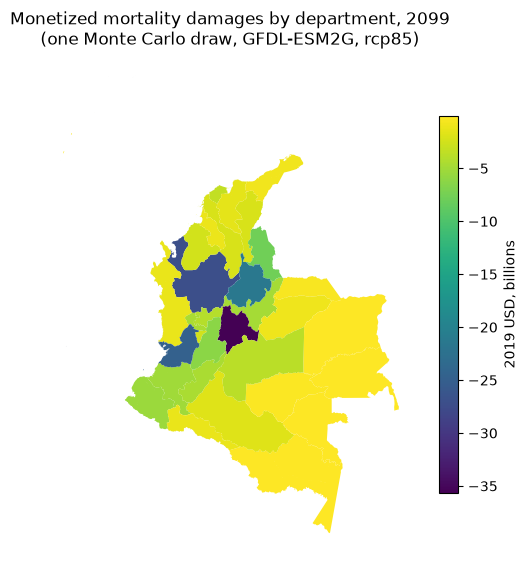

In [4]:
import geopandas as gpd

shapes = gpd.read_parquet(DATA / "col_adm1_plot.parquet")
m = shapes.merge(d99, on=["ISO", "ID_1"])
m["billions"] = m["total_damages"] / 1e9
ax = m.plot(column="billions", legend=True, cmap="viridis", figsize=(6, 7),
            legend_kwds={"label": "2019 USD, billions", "shrink": 0.7})
ax.set_title("Monetized mortality damages by department, 2099\n(one Monte Carlo draw, GFDL-ESM2G, rcp85)")
ax.set_axis_off()

## Statistics over the sample

Statistics come last, after spatial aggregation: quantiles do not pass
through sums, so each draw is aggregated separately and pooled at the
end. With only two draws these quantiles show the mechanics, nothing
more; a full run pools hundreds.

In [5]:
frames = []
for batch in ("batch0", "batch1"):
    leaf = DATA / "montecarlo" / batch / "rcp85" / "GFDL-ESM2G" / "low" / "SSP3" / "mortality_damages_IR_batch.nc4"
    data = cilreg.read_netcdf_leaf(leaf, variables=["total_damages"],
                                   region_dim="region", region_col="hierid",
                                   kind="extensive")
    applied = cilreg.apply_weights(
        weights, data, kind="extensive", weight="pop",
        value_col="total_damages", data_version=DATA_VERSION,
        restrict_to_sources=col_regions,
    )
    frames.append(applied.frame.assign(batch=batch))

stats = cilreg.summarize_samples(
    pd.concat(frames, ignore_index=True),
    sample_dims=["batch"], time_col="year", window=(2080, 2099),
    value_col="total_damages", quantiles=[0.05, 0.5, 0.95],
)
stats[stats["ID_1"] == 1]

,ISO,ID_1,statistic,total_damages
0,COL,1,mean,-4.022969e+07
32,COL,1,q05,-1.483635e+08
64,COL,1,q50,-4.022969e+07
96,COL,1,q95,6.790414e+07


## Where to go from here

Rates (deaths per person per year) are the intensive case: the
`per_destination` weights average over the regions inside each unit
instead of splitting totals. The script next to this notebook,
`run_example.py`, runs both kinds at ADM1 and ADM2 from the command
line and has an `--offline` mode that uses committed weight slices
instead of fetching. The README in this directory shows its full
output.